# Data Analysis and Preprocessing for Thermal Stability Dataset

# Install Dependencies

In [2]:
!pip install scikit-optimize
!pip install numpy pandas scikit-learn bayesian-optimization matplotlib seaborn optuna scikit-optimize
!pip install pandas seaborn matplotlib numpy scipy scikit-learn xgboost scikit-optimize bayesian-optimization


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importing all the dependencies

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import uniform, randint, loguniform
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, root_mean_squared_error, mean_absolute_error, r2_score, mean_squared_error
from skopt import BayesSearchCV
from sklearn.linear_model import Ridge
from bayes_opt import BayesianOptimization
from skopt.space import Real, Categorical, Integer
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor

### Loading dataset from Github [It may take some time]

In [4]:
#https://raw.githubusercontent.com/Shown246/CSE445_Datasets/refs/heads/main/thermal-stability.csv
df = pd.read_csv('https://raw.githubusercontent.com/Shown246/CSE445_Datasets/refs/heads/main/thermal-stability.csv')
df.head()

,waveguide_material,cladding_material,waveguide_width,waveguide_height,temperature_min,temperature_max,temperature_step,thermal_expansion_coefficient,thermal_conductivity,refractive_index_core,...,thermal_tuning_efficiency,thermal_stress,strain_rate,optical_power_input,optical_power_output_min,optical_power_output_max,wavelength_min,wavelength_max,simulation_model,measurement_uncertainty
0,SU-8,Air,1.780,0.325,9.7,97.8,1,6.530000e-06,0.25,1.78614,...,63.70,66.62,0.000004,9.53,9.10,9.39,1260,1625,Finite Element Method (FEM),2.80
1,Polymethyl Methacrylate (PMMA),Air,1.660,0.484,-28.1,173.5,1,1.123000e-05,0.19,1.99646,...,78.91,47.13,0.000001,8.25,8.04,7.98,1260,1625,Finite Element Method (FEM),4.38
2,Polydimethylsiloxane (PDMS),Silicon Dioxide (SiO₂),1.493,0.377,-12.9,87.2,5,1.561800e-04,0.17,1.89949,...,80.75,52.69,0.000004,9.83,9.67,9.69,1260,1625,FDTD,3.90
3,Silicon Dioxide (SiO₂),Silicon Dioxide (SiO₂),1.439,0.823,9.8,148.7,1,7.200000e-07,1.48,1.67669,...,89.10,87.37,0.000004,5.27,4.82,5.06,1260,1625,FDTD,4.60
4,SU-8,Air,1.067,0.319,-37.5,156.8,5,9.210000e-06,0.22,1.46767,...,54.43,37.25,0.000002,4.51,4.37,4.26,1260,1625,Finite Element Method (FEM),4.60


### Checking for missing values

In [5]:
# Checking missing values
df.isnull().sum()

waveguide_material               0
cladding_material                0
waveguide_width                  0
waveguide_height                 0
temperature_min                  0
temperature_max                  0
temperature_step                 0
thermal_expansion_coefficient    0
thermal_conductivity             0
refractive_index_core            0
refractive_index_cladding        0
propagation_loss_min             0
propagation_loss_max             0
effective_index_min              0
effective_index_max              0
dn_dT                            0
thermal_tuning_efficiency        0
thermal_stress                   0
strain_rate                      0
optical_power_input              0
optical_power_output_min         0
optical_power_output_max         0
wavelength_min                   0
wavelength_max                   0
simulation_model                 0
measurement_uncertainty          0
dtype: int64

### Statistical features of the dataset

In [6]:
df.describe()

,waveguide_width,waveguide_height,temperature_min,temperature_max,temperature_step,thermal_expansion_coefficient,thermal_conductivity,refractive_index_core,refractive_index_cladding,propagation_loss_min,...,dn_dT,thermal_tuning_efficiency,thermal_stress,strain_rate,optical_power_input,optical_power_output_min,optical_power_output_max,wavelength_min,wavelength_max,measurement_uncertainty
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.0,100000.0,100000.000000
mean,1.252935,0.599759,-15.027613,139.922015,5.322680,4.503634e-05,3.915528,1.700474,1.251085,1.548305,...,0.000038,69.971498,55.040140,2.549927e-06,5.250169,4.949694,4.950034,1260.0,1625.0,2.550175
std,0.432870,0.230406,20.246527,34.714554,3.680393,8.216336e-05,6.851416,0.173286,0.144389,0.837346,...,0.000022,11.535965,25.979577,1.416079e-06,2.739690,2.742474,2.741749,0.0,0.0,1.415007
min,0.500000,0.200000,-50.000000,80.000000,1.000000,5.000000e-07,0.150000,1.400000,1.000010,0.100000,...,0.000004,50.000000,10.000000,1.000000e-07,0.500000,0.000000,0.000000,1260.0,1625.0,0.100000
25%,0.880000,0.400000,-32.600000,109.800000,1.000000,2.760000e-06,0.200000,1.550160,1.126267,0.823000,...,0.000021,60.010000,32.570000,1.320000e-06,2.880000,2.580000,2.580000,1260.0,1625.0,1.320000
50%,1.253500,0.600000,-15.000000,139.900000,5.000000,8.160000e-06,0.250000,1.700915,1.252390,1.549000,...,0.000036,69.950000,55.055000,2.550000e-06,5.245000,4.950000,4.940000,1260.0,1625.0,2.550000
75%,1.628000,0.799000,2.600000,170.000000,10.000000,1.301000e-05,1.450000,1.850210,1.375640,2.269000,...,0.000051,79.990000,77.590000,3.780000e-06,7.620000,7.320000,7.320000,1260.0,1625.0,3.770000
max,2.000000,1.000000,20.000000,200.000000,10.000000,2.999900e-04,20.000000,2.000000,1.500000,3.000000,...,0.000160,90.000000,100.000000,5.000000e-06,10.000000,9.890000,9.890000,1260.0,1625.0,5.000000


### Showing Boxplot to view Outliers

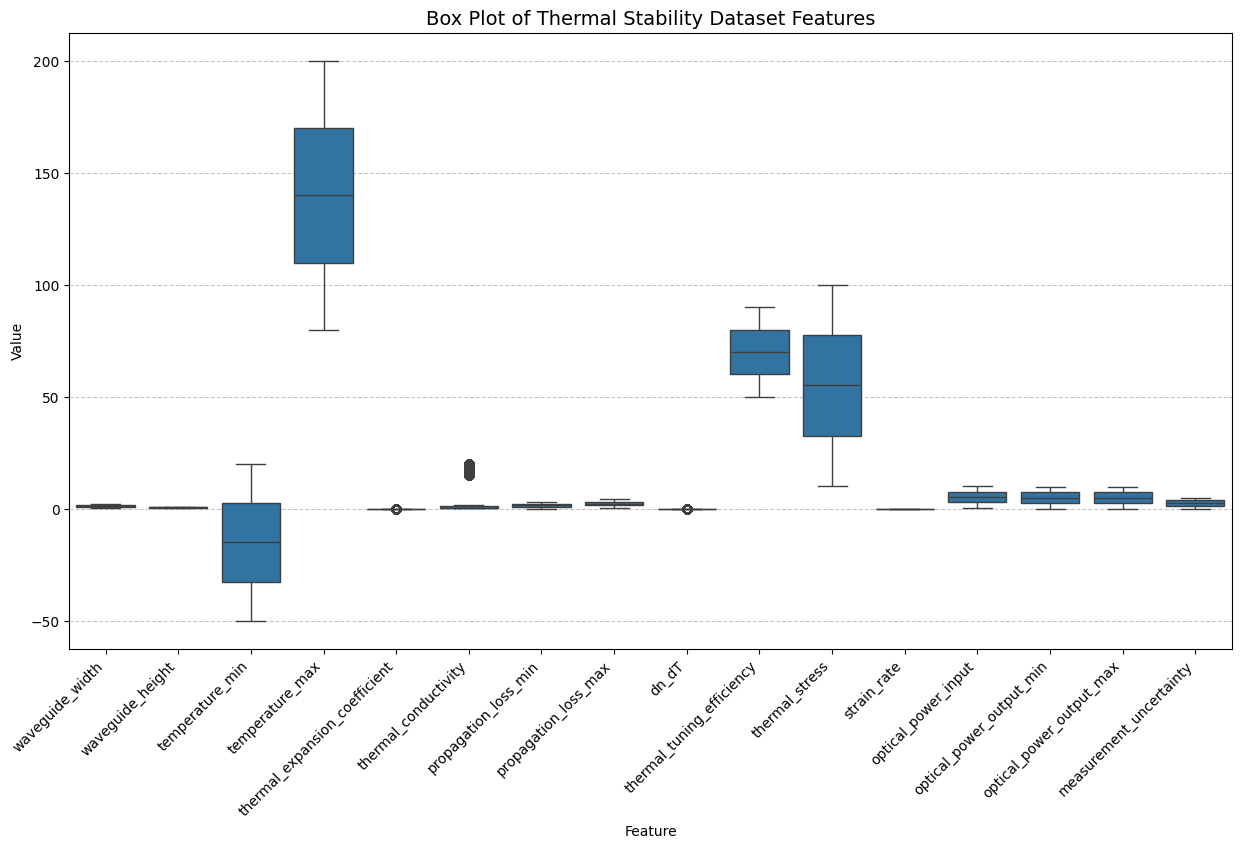

In [7]:
# List of columns for box plots
columns_for_boxplot = [
    "waveguide_width", "waveguide_height",  # Waveguide Dimensions
    "temperature_min", "temperature_max",   # Thermal Parameters
    "thermal_expansion_coefficient", "thermal_conductivity",
    "propagation_loss_min", "propagation_loss_max",  # Optical Performance
    "dn_dT", "thermal_tuning_efficiency",
    "thermal_stress", "strain_rate",  # Environmental and Operational
    "optical_power_input", "optical_power_output_min", "optical_power_output_max",
    "measurement_uncertainty"  # Simulation and Metadata
]

# Melt the dataframe to long format for seaborn
df_melted = df[columns_for_boxplot].melt(var_name="Feature", value_name="Value")

# Create a single box plot
plt.figure(figsize=(15, 8))
sns.boxplot(x="Feature", y="Value", data=df_melted)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha="right")
plt.title("Box Plot of Thermal Stability Dataset Features", fontsize=14)
plt.xlabel("Feature")
plt.ylabel("Value")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Analysis Statistical Outlier detection

### Z Score

In [8]:
# Z-score outlier detection
# Select numerical columns
columns_to_check = df.select_dtypes(include=['float64', 'int64']).columns
# Compute Z-score
z_scores = np.abs(stats.zscore(df[columns_to_check]))

# Identify row indices containing outliers
outliers_indices = df[(z_scores > 3).any(axis=1)].index

# Total number of outliers
total_outliers = len(outliers_indices)
print(f"Total number of outliers: {total_outliers}")
# Remove outliers
df = df.drop(outliers_indices)
df.shape

Total number of outliers: 1963


C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_10612\3253582516.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(stats.zscore(df[columns_to_check]))


(98037, 26)

### Interquantile Range

In [9]:
# IQR calculation
Q1 = df[columns_to_check].quantile(0.25)  # 25th percentile (Q1)
Q3 = df[columns_to_check].quantile(0.75)  # 75th percentile (Q3)
IQR = Q3 - Q1  # Interquartile Range

# Identify outliers
# Outliers are values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
outliers_mask = (df[columns_to_check] < (Q1 - 1.5 * IQR)) | (df[columns_to_check] > (Q3 + 1.5 * IQR))

# Filter rows with at least one outlier
outliers_df = df[outliers_mask.any(axis=1)]

# Print results
print("Outliers detected using IQR:", outliers_df.shape[0])  # Number of rows with outliers
print("Outliers per column:")
print(outliers_mask.sum())  # Count of outliers in each column

Outliers detected using IQR: 39398
Outliers per column:
waveguide_width                      0
waveguide_height                     0
temperature_min                      0
temperature_max                      0
temperature_step                     0
thermal_expansion_coefficient    19054
thermal_conductivity             19824
refractive_index_core                0
refractive_index_cladding            0
propagation_loss_min                 0
propagation_loss_max                 0
effective_index_min                  0
effective_index_max                  0
dn_dT                              889
thermal_tuning_efficiency            0
thermal_stress                       0
strain_rate                          0
optical_power_input                  0
optical_power_output_min             0
optical_power_output_max             0
wavelength_min                       0
wavelength_max                       0
measurement_uncertainty              0
dtype: int64


## Machine Learning Method to detect Outlier

### Isolation Forest

In [10]:
# Drop missing values for Isolation Forest analysis
df_clean = df[columns_to_check].dropna()

# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_clean['Outlier'] = iso_forest.fit_predict(df_clean)

# -1 indicates outliers
outliers_iso = df_clean[df_clean['Outlier'] == -1]

# Show the number of outliers detected
print("Outliers detected using Isolation Forest:", outliers_iso.shape[0])
outliers_iso.head()


Outliers detected using Isolation Forest: 4902


,waveguide_width,waveguide_height,temperature_min,temperature_max,temperature_step,thermal_expansion_coefficient,thermal_conductivity,refractive_index_core,refractive_index_cladding,propagation_loss_min,...,thermal_tuning_efficiency,thermal_stress,strain_rate,optical_power_input,optical_power_output_min,optical_power_output_max,wavelength_min,wavelength_max,measurement_uncertainty,Outlier
57,1.606,0.794,11.5,87.2,1,0.000129,0.16,1.60682,1.47719,2.479,...,53.54,35.22,4.650000e-06,1.54,1.07,1.23,1260,1625,2.15,-1
87,0.989,0.847,-7.7,107.5,10,0.000289,0.20,1.51824,1.00199,2.484,...,81.32,61.37,4.500000e-07,9.66,9.50,9.26,1260,1625,1.48,-1
112,0.808,0.310,18.8,196.9,1,0.000121,0.20,1.43054,1.21916,0.276,...,75.53,48.85,3.600000e-06,7.47,7.10,7.01,1260,1625,2.76,-1
113,1.795,0.877,16.0,110.2,10,0.000208,0.19,1.67965,1.01518,1.899,...,57.28,96.16,3.150000e-06,7.36,7.22,7.13,1260,1625,4.95,-1
159,1.874,0.723,8.7,194.2,10,0.000170,0.19,1.67207,1.12165,0.840,...,52.08,51.71,3.490000e-06,0.74,0.32,0.36,1260,1625,0.10,-1


### Local Outlier Factor

In [11]:
# Clean dataset by dropping NaN values (if any)
df_clean = df[columns_to_check].dropna()

# Apply Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20)
outliers_lof = lof.fit_predict(df_clean)

# Create a new column for outliers (-1 means outlier, 1 means inlier)
df_clean['Outlier'] = outliers_lof

# -1 indicates outliers
df_lof_outliers = df_clean[df_clean['Outlier'] == -1]

# Show the number of outliers detected
print("Outliers detected using LOF:", df_lof_outliers.shape[0])

# Display first few detected outliers
df_lof_outliers.head()

Outliers detected using LOF: 0


,waveguide_width,waveguide_height,temperature_min,temperature_max,temperature_step,thermal_expansion_coefficient,thermal_conductivity,refractive_index_core,refractive_index_cladding,propagation_loss_min,...,thermal_tuning_efficiency,thermal_stress,strain_rate,optical_power_input,optical_power_output_min,optical_power_output_max,wavelength_min,wavelength_max,measurement_uncertainty,Outlier


In [12]:
correlation = df[columns_to_check].corr()["thermal_expansion_coefficient"].sort_values(ascending=False)
print(correlation)

thermal_expansion_coefficient    1.000000
dn_dT                            0.006197
temperature_step                 0.005508
effective_index_max              0.004659
effective_index_min              0.004558
measurement_uncertainty          0.002823
propagation_loss_max             0.002809
refractive_index_core            0.001975
refractive_index_cladding        0.000719
propagation_loss_min             0.000212
waveguide_height                 0.000041
thermal_tuning_efficiency       -0.000588
waveguide_width                 -0.001381
strain_rate                     -0.001763
optical_power_output_min        -0.002572
optical_power_output_max        -0.002632
optical_power_input             -0.002640
temperature_min                 -0.002777
temperature_max                 -0.004519
thermal_stress                  -0.005465
thermal_conductivity            -0.277445
wavelength_min                        NaN
wavelength_max                        NaN
Name: thermal_expansion_coefficien

In [13]:
# Drop the columns
columns_to_drop = ["thermal_expansion_coefficient", "thermal_conductivity"]
df = df.drop(columns=columns_to_drop)

In [14]:
# IQR calculation
# Columns to check for outliers
columns_to_check = df.select_dtypes(include=['float64','int64']).columns
Q1 = df[columns_to_check].quantile(0.25)
Q3 = df[columns_to_check].quantile(0.75)
IQR = Q3 - Q1

# Find outliers
outliers_mask = (df[columns_to_check] < (Q1 - 1.5 * IQR)) | (df[columns_to_check] > (Q3 + 1.5 * IQR))
outlier_IF = df[outliers_mask.any(axis=1)]

# Print results
print("Outliers detected using IQR:", outlier_IF.shape[0])
print("Outliers per column:")
print(outliers_mask.sum())
# Drop outliers
df = df.drop(outlier_IF.index)
df.shape

Outliers detected using IQR: 889
Outliers per column:
waveguide_width                0
waveguide_height               0
temperature_min                0
temperature_max                0
temperature_step               0
refractive_index_core          0
refractive_index_cladding      0
propagation_loss_min           0
propagation_loss_max           0
effective_index_min            0
effective_index_max            0
dn_dT                        889
thermal_tuning_efficiency      0
thermal_stress                 0
strain_rate                    0
optical_power_input            0
optical_power_output_min       0
optical_power_output_max       0
wavelength_min                 0
wavelength_max                 0
measurement_uncertainty        0
dtype: int64


(97148, 24)

### Showing Box plot again after handling Outliers

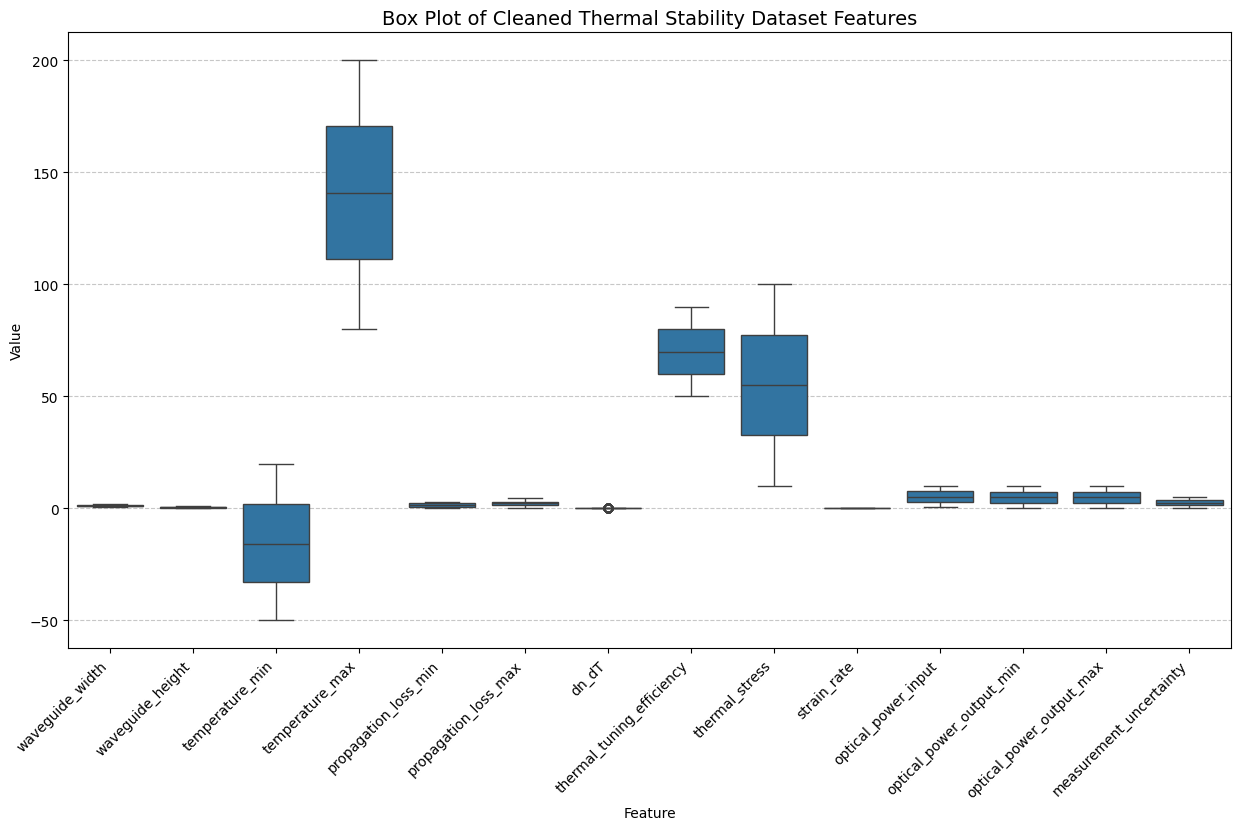

In [15]:
# Box plot of the cleaned dataset
columns_for_boxplot = [
    "waveguide_width", "waveguide_height",  # Waveguide Dimensions
    "temperature_min", "temperature_max",   # Thermal Parameters
    "propagation_loss_min", "propagation_loss_max",  # Optical Performance
    "dn_dT", "thermal_tuning_efficiency",
    "thermal_stress", "strain_rate",  # Environmental and Operational
    "optical_power_input", "optical_power_output_min", "optical_power_output_max",
    "measurement_uncertainty"  # Simulation and Metadata
]
df_melted1 = df[columns_for_boxplot].melt(var_name="Feature", value_name="Value")
plt.figure(figsize=(15, 8))
sns.boxplot(x="Feature", y="Value", data=df_melted1)
plt.xticks(rotation=45, ha="right")
plt.title("Box Plot of Cleaned Thermal Stability Dataset Features", fontsize=14)
plt.xlabel("Feature")
plt.ylabel("Value")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Encoding

In [16]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols.tolist())

# Display unique values in categorical columns
for col in categorical_cols:
    print(f"\nUnique values in '{col}': {df[col].unique()}")


Categorical columns: ['waveguide_material', 'cladding_material', 'simulation_model']

Unique values in 'waveguide_material': ['SU-8' 'Polymethyl Methacrylate (PMMA)' 'Polydimethylsiloxane (PDMS)'
 'Silicon Dioxide (SiO₂)' 'Silicon Nitride (Si₃N₄)']

Unique values in 'cladding_material': ['Air' 'Silicon Dioxide (SiO₂)']

Unique values in 'simulation_model': ['Finite Element Method (FEM)' 'FDTD']


## Encoding Binary Categorical features
### Manually encoding to avoid Bias

In [17]:
# Manually encode binary categorical features for consistency
df["cladding_material"] = df["cladding_material"].map({"Air": 0, "Silicon Dioxide (SiO₂)": 1})
df["simulation_model"] = df["simulation_model"].map({"Finite Element Method (FEM)": 0, "FDTD": 1})

# Apply One-Hot Encoding for `waveguide_material`
df = pd.get_dummies(df, columns=["waveguide_material"])
# Convert boolean to integer (0/1)
df[df.select_dtypes('bool').columns] = df.select_dtypes('bool').astype(int)
# Display encoded dataset
df.head()

,cladding_material,waveguide_width,waveguide_height,temperature_min,temperature_max,temperature_step,refractive_index_core,refractive_index_cladding,propagation_loss_min,propagation_loss_max,...,optical_power_output_max,wavelength_min,wavelength_max,simulation_model,measurement_uncertainty,waveguide_material_Polydimethylsiloxane (PDMS),waveguide_material_Polymethyl Methacrylate (PMMA),waveguide_material_SU-8,waveguide_material_Silicon Dioxide (SiO₂),waveguide_material_Silicon Nitride (Si₃N₄)
0,0,1.780,0.325,9.7,97.8,1,1.78614,1.12785,2.636,3.782,...,9.39,1260,1625,0,2.80,0,0,1,0,0
1,0,1.660,0.484,-28.1,173.5,1,1.99646,1.32424,2.521,2.952,...,7.98,1260,1625,0,4.38,0,1,0,0,0
2,1,1.493,0.377,-12.9,87.2,5,1.89949,1.21620,2.063,3.367,...,9.69,1260,1625,1,3.90,1,0,0,0,0
3,1,1.439,0.823,9.8,148.7,1,1.67669,1.27030,0.508,0.892,...,5.06,1260,1625,1,4.60,0,0,0,1,0
4,0,1.067,0.319,-37.5,156.8,5,1.46767,1.04754,2.397,3.428,...,4.26,1260,1625,0,4.60,0,0,1,0,0


## Scalling

### Plotting Histrograms to see data distrubustions

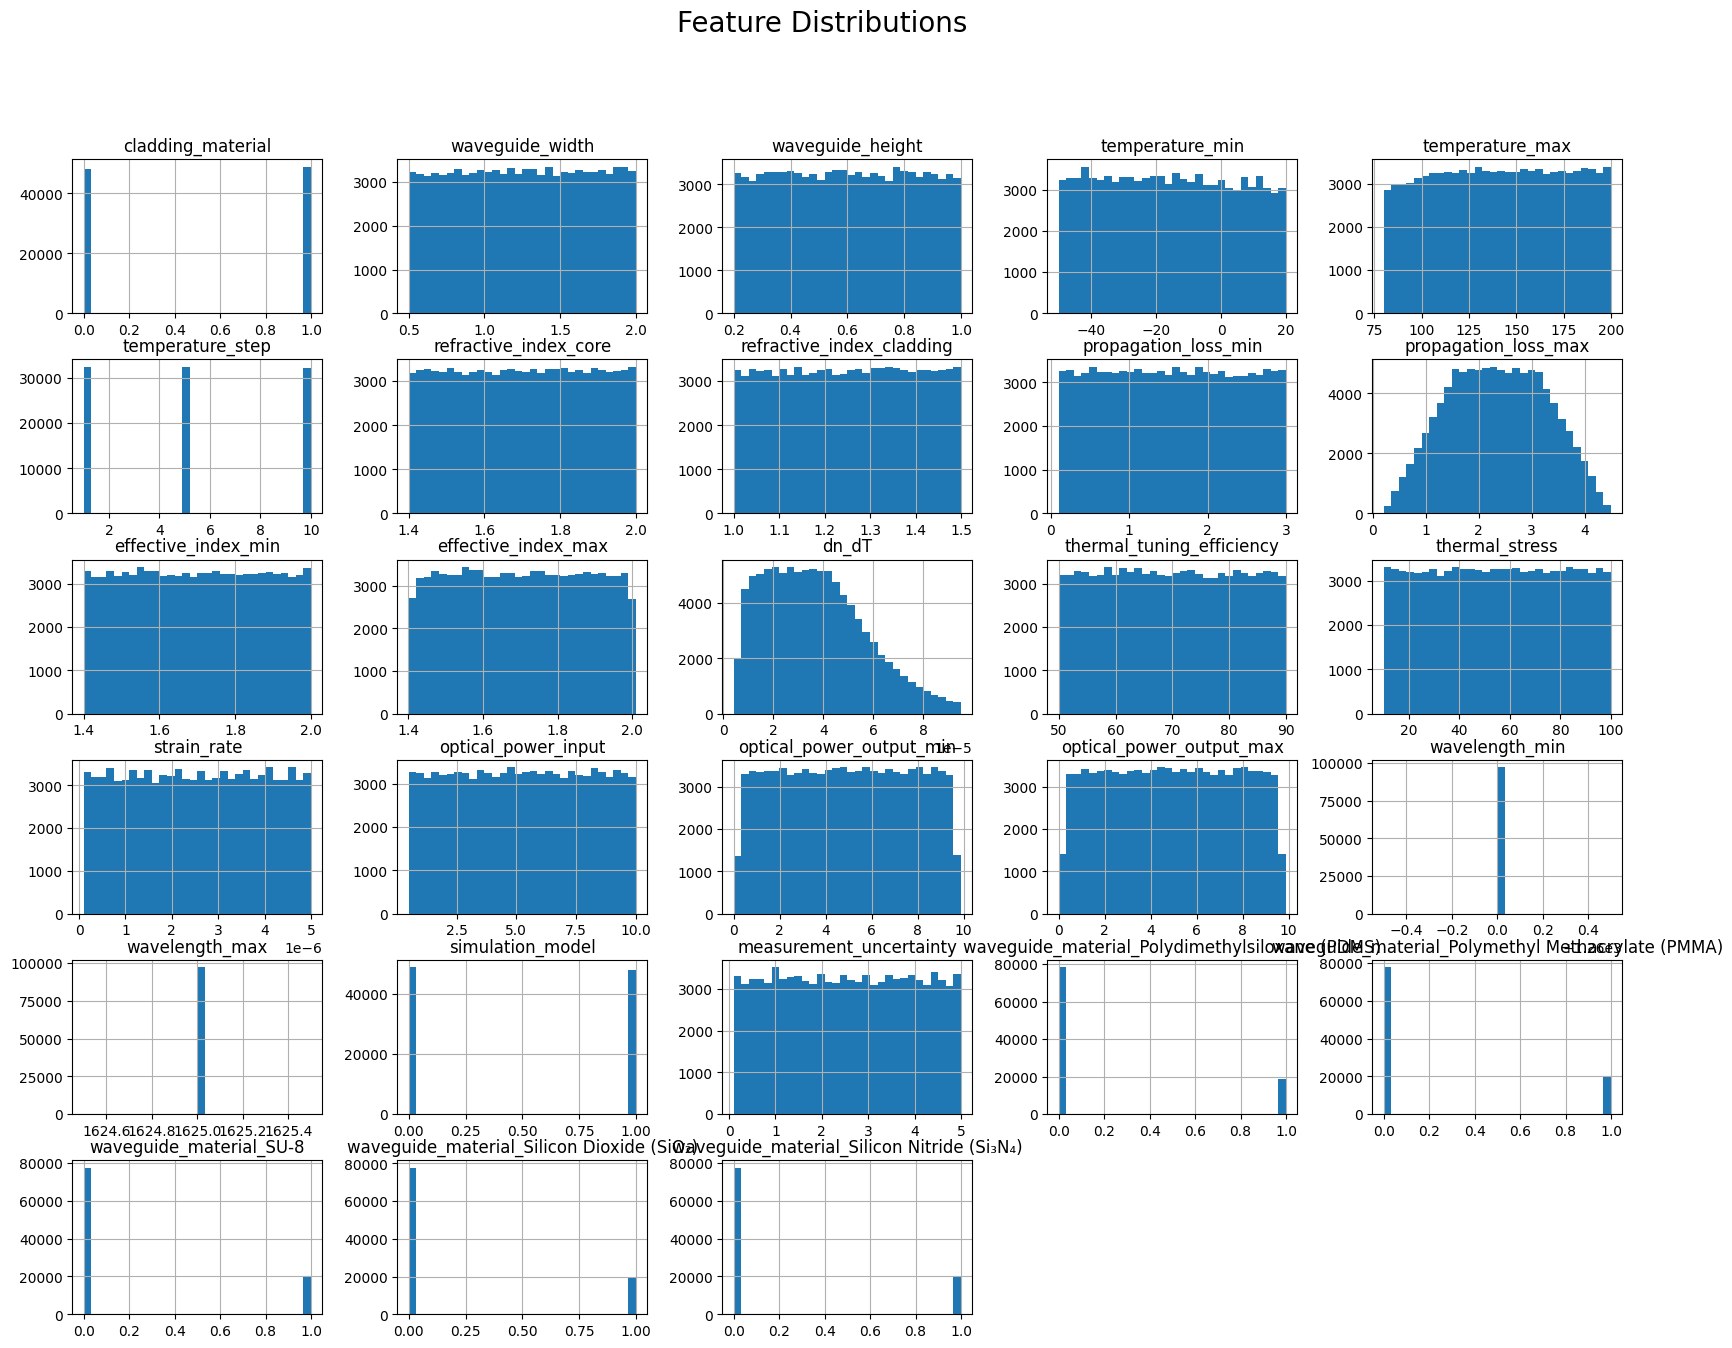

In [18]:
# Plot histograms for all numerical features
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_features].hist(bins=30, figsize=(20, 15))
plt.suptitle('Feature Distributions', fontsize=20)
plt.show()

In [19]:
# List of features to exclude (adjust if needed)
exclude_features = [
    'waveguide_material', 'cladding_material', 'simulation_model',
    'temperature_step'
]
# Select numerical features excluding the ones above
numerical_features = [col for col in df.columns if col not in exclude_features]
print(numerical_features)


['waveguide_width', 'waveguide_height', 'temperature_min', 'temperature_max', 'refractive_index_core', 'refractive_index_cladding', 'propagation_loss_min', 'propagation_loss_max', 'effective_index_min', 'effective_index_max', 'dn_dT', 'thermal_tuning_efficiency', 'thermal_stress', 'strain_rate', 'optical_power_input', 'optical_power_output_min', 'optical_power_output_max', 'wavelength_min', 'wavelength_max', 'measurement_uncertainty', 'waveguide_material_Polydimethylsiloxane (PDMS)', 'waveguide_material_Polymethyl Methacrylate (PMMA)', 'waveguide_material_SU-8', 'waveguide_material_Silicon Dioxide (SiO₂)', 'waveguide_material_Silicon Nitride (Si₃N₄)']


In [20]:
print(df.head())

   cladding_material  waveguide_width  waveguide_height  temperature_min  \
0                  0            1.780             0.325              9.7   
1                  0            1.660             0.484            -28.1   
2                  1            1.493             0.377            -12.9   
3                  1            1.439             0.823              9.8   
4                  0            1.067             0.319            -37.5   

   temperature_max  temperature_step  refractive_index_core  \
0             97.8                 1                1.78614   
1            173.5                 1                1.99646   
2             87.2                 5                1.89949   
3            148.7                 1                1.67669   
4            156.8                 5                1.46767   

   refractive_index_cladding  propagation_loss_min  propagation_loss_max  ...  \
0                    1.12785                 2.636                 3.782  ...   
1 

### Applying Standard Scaling to Normal distrubution data

In [21]:
scaler = StandardScaler()

# Fit and transform the numerical features
df_scaled = df.copy()
df_scaled[numerical_features] = scaler.fit_transform(df[numerical_features])

# Check the result
print(df_scaled.head())


   cladding_material  waveguide_width  waveguide_height  temperature_min  \
0                  0         1.216288         -1.192365         1.253003   
1                  0         0.939236         -0.502219        -0.625370   
2                  1         0.553672         -0.966657         0.129955   
3                  1         0.428999          0.969225         1.257973   
4                  0        -0.429863         -1.218408        -1.092479   

   temperature_max  temperature_step  refractive_index_core  \
0        -1.255501                 1               0.493670   
1         0.949504                 1               1.707225   
2        -1.564260                 5               1.147704   
3         0.227125                 1              -0.137861   
4         0.463063                 5              -1.343916   

   refractive_index_cladding  propagation_loss_min  propagation_loss_max  ...  \
0                  -0.852865              1.299475              1.541624  ...   
1 

### Before and After Scaling

In [22]:
df.describe()

,cladding_material,waveguide_width,waveguide_height,temperature_min,temperature_max,temperature_step,refractive_index_core,refractive_index_cladding,propagation_loss_min,propagation_loss_max,...,optical_power_output_max,wavelength_min,wavelength_max,simulation_model,measurement_uncertainty,waveguide_material_Polydimethylsiloxane (PDMS),waveguide_material_Polymethyl Methacrylate (PMMA),waveguide_material_SU-8,waveguide_material_Silicon Dioxide (SiO₂),waveguide_material_Silicon Nitride (Si₃N₄)
count,97148.000000,97148.000000,97148.000000,97148.000000,97148.000000,97148.000000,97148.000000,97148.000000,97148.000000,97148.000000,...,97148.000000,97148.0,97148.0,97148.000000,97148.000000,97148.000000,97148.000000,97148.000000,97148.000000,97148.000000
mean,0.503345,1.253187,0.599704,-15.515184,140.902576,5.319790,1.700583,1.251000,1.547842,2.351177,...,4.950403,1260.0,1625.0,0.496325,2.549652,0.194404,0.200900,0.202773,0.199932,0.201991
std,0.499991,0.433134,0.230387,20.123901,34.331161,3.680068,0.173310,0.144396,0.837387,0.928132,...,2.742398,0.0,0.0,0.499989,1.415782,0.395744,0.400675,0.402067,0.399951,0.401487
min,0.000000,0.500000,0.200000,-50.000000,80.000000,1.000000,1.400000,1.000010,0.100000,0.205000,...,0.000000,1260.0,1625.0,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.880000,0.400000,-32.900000,111.500000,1.000000,1.550190,1.126208,0.823000,1.623000,...,2.580000,1260.0,1625.0,0.000000,1.320000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.254000,0.600000,-15.700000,141.000000,5.000000,1.701050,1.252220,1.548000,2.347000,...,4.950000,1260.0,1625.0,0.000000,2.550000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.628000,0.799000,1.800000,170.600000,10.000000,1.850493,1.375602,2.268000,3.076000,...,7.320000,1260.0,1625.0,1.000000,3.770000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,2.000000,1.000000,20.000000,200.000000,10.000000,2.000000,1.499990,3.000000,4.496000,...,9.890000,1260.0,1625.0,1.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [23]:
df_scaled.describe()

,cladding_material,waveguide_width,waveguide_height,temperature_min,temperature_max,temperature_step,refractive_index_core,refractive_index_cladding,propagation_loss_min,propagation_loss_max,...,optical_power_output_max,wavelength_min,wavelength_max,simulation_model,measurement_uncertainty,waveguide_material_Polydimethylsiloxane (PDMS),waveguide_material_Polymethyl Methacrylate (PMMA),waveguide_material_SU-8,waveguide_material_Silicon Dioxide (SiO₂),waveguide_material_Silicon Nitride (Si₃N₄)
count,97148.000000,9.714800e+04,9.714800e+04,9.714800e+04,9.714800e+04,97148.000000,9.714800e+04,9.714800e+04,9.714800e+04,9.714800e+04,...,9.714800e+04,97148.0,97148.0,97148.000000,9.714800e+04,9.714800e+04,9.714800e+04,9.714800e+04,9.714800e+04,9.714800e+04
mean,0.503345,4.987067e-16,-1.462805e-16,-6.743529e-17,-2.770552e-16,5.319790,-1.162564e-16,1.487672e-16,5.529402e-17,-5.119816e-16,...,-1.591531e-16,0.0,0.0,0.496325,4.797999e-17,-5.361179e-17,-5.650083e-17,-2.633048e-17,-1.974786e-18,-1.404292e-17
std,0.499991,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,3.680068,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,...,1.000005e+00,0.0,0.0,0.499989,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,0.000000,-1.738934e+00,-1.734933e+00,-1.713634e+00,-1.773983e+00,1.000000,-1.734375e+00,-1.738211e+00,-1.729010e+00,-2.312375e+00,...,-1.805146e+00,0.0,0.0,0.000000,-1.730255e+00,-4.912409e-01,-5.014053e-01,-5.043293e-01,-4.998938e-01,-5.031087e-01
25%,0.000000,-8.616022e-01,-8.668246e-01,-8.638934e-01,-8.564443e-01,1.000000,-8.677718e-01,-8.642401e-01,-8.656050e-01,-7.845668e-01,...,-8.643587e-01,0.0,0.0,0.000000,-8.685365e-01,-4.912409e-01,-5.014053e-01,-5.043293e-01,-4.998938e-01,-5.031087e-01
50%,1.000000,1.876687e-03,1.283916e-03,-9.183950e-03,2.837772e-03,5.000000,2.696844e-03,8.449948e-03,1.881745e-04,-4.500970e-03,...,-1.470626e-04,0.0,0.0,0.000000,2.454563e-04,-4.912409e-01,-5.014053e-01,-5.043293e-01,-4.998938e-01,-5.031087e-01
75%,1.000000,8.653556e-01,8.650519e-01,8.604332e-01,8.650327e-01,10.000000,8.649865e-01,8.629261e-01,8.600104e-01,7.809520e-01,...,8.640646e-01,0.0,0.0,1.000000,8.619642e-01,-4.912409e-01,-5.014053e-01,-5.043293e-01,-4.998938e-01,-5.031087e-01
max,1.000000,1.724217e+00,1.737501e+00,1.764835e+00,1.721402e+00,10.000000,1.727651e+00,1.724362e+00,1.734163e+00,2.310915e+00,...,1.801206e+00,0.0,0.0,1.000000,1.730746e+00,2.035661e+00,1.994394e+00,1.982832e+00,2.000425e+00,1.987642e+00


In [24]:
df=df_scaled

## # Exploratory Data Analysis

C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_10612\4040759365.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df["waveguide_width"], shade=True)


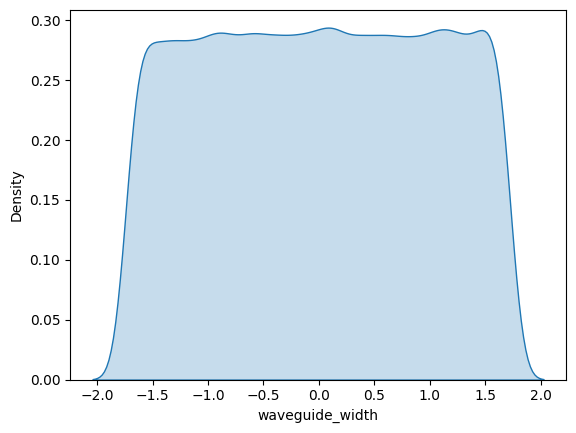

In [25]:
sns.kdeplot(df["waveguide_width"], shade=True)
plt.show()

### Bar plots for binary and categorical features Vs Counts

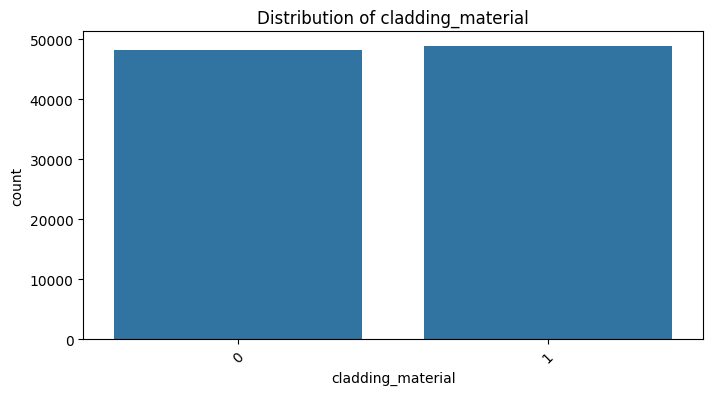

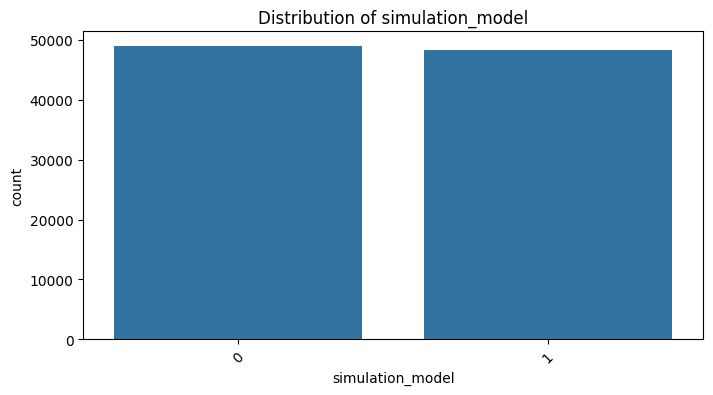

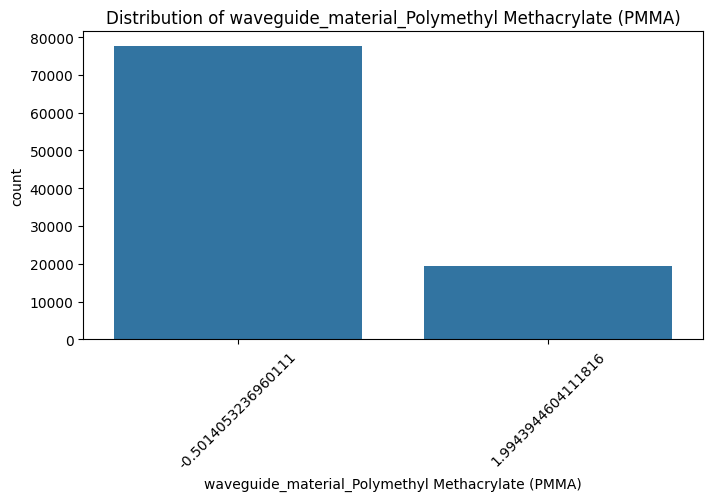

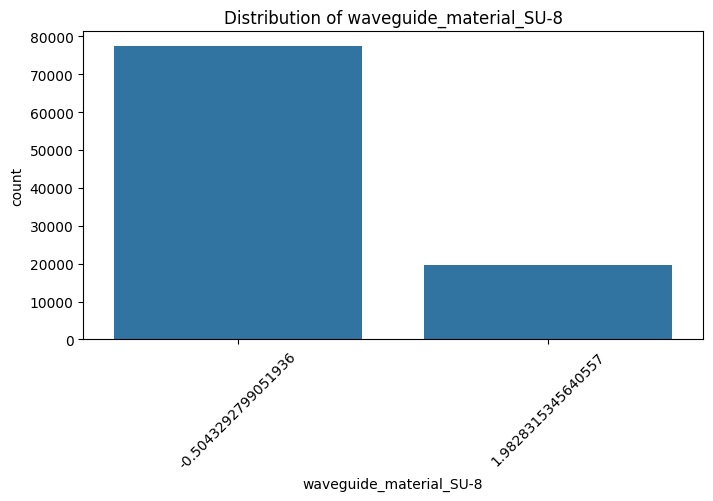

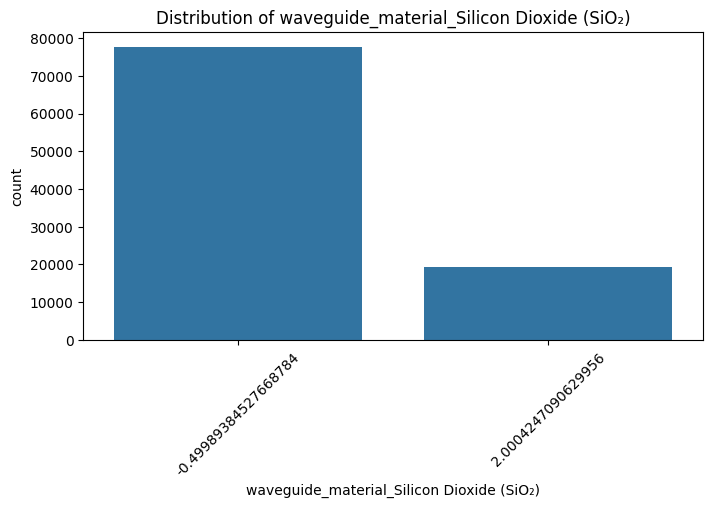

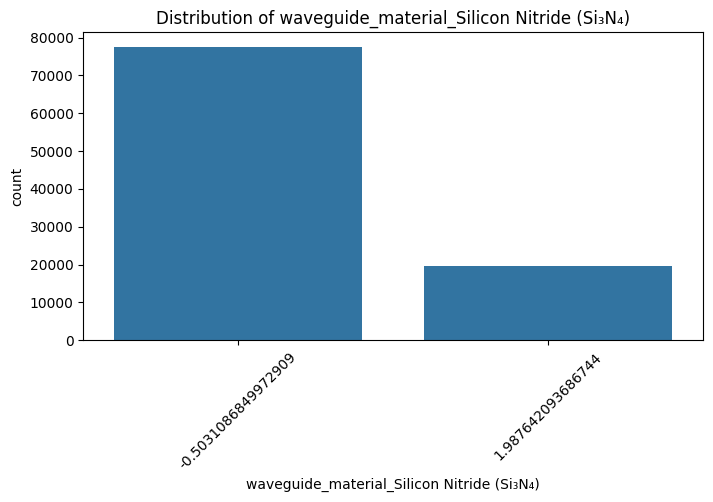

In [26]:
for col in ["cladding_material", "simulation_model",
            "waveguide_material_Polymethyl Methacrylate (PMMA)",
            "waveguide_material_SU-8",
            "waveguide_material_Silicon Dioxide (SiO₂)",
            "waveguide_material_Silicon Nitride (Si₃N₄)"]:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.countplot(x=df[col])
        plt.xticks(rotation=45)
        plt.title(f"Distribution of {col}")
        plt.show()
    else:
        print(f"Column {col} does not exist in the dataframe.")


### Correlation Matrix

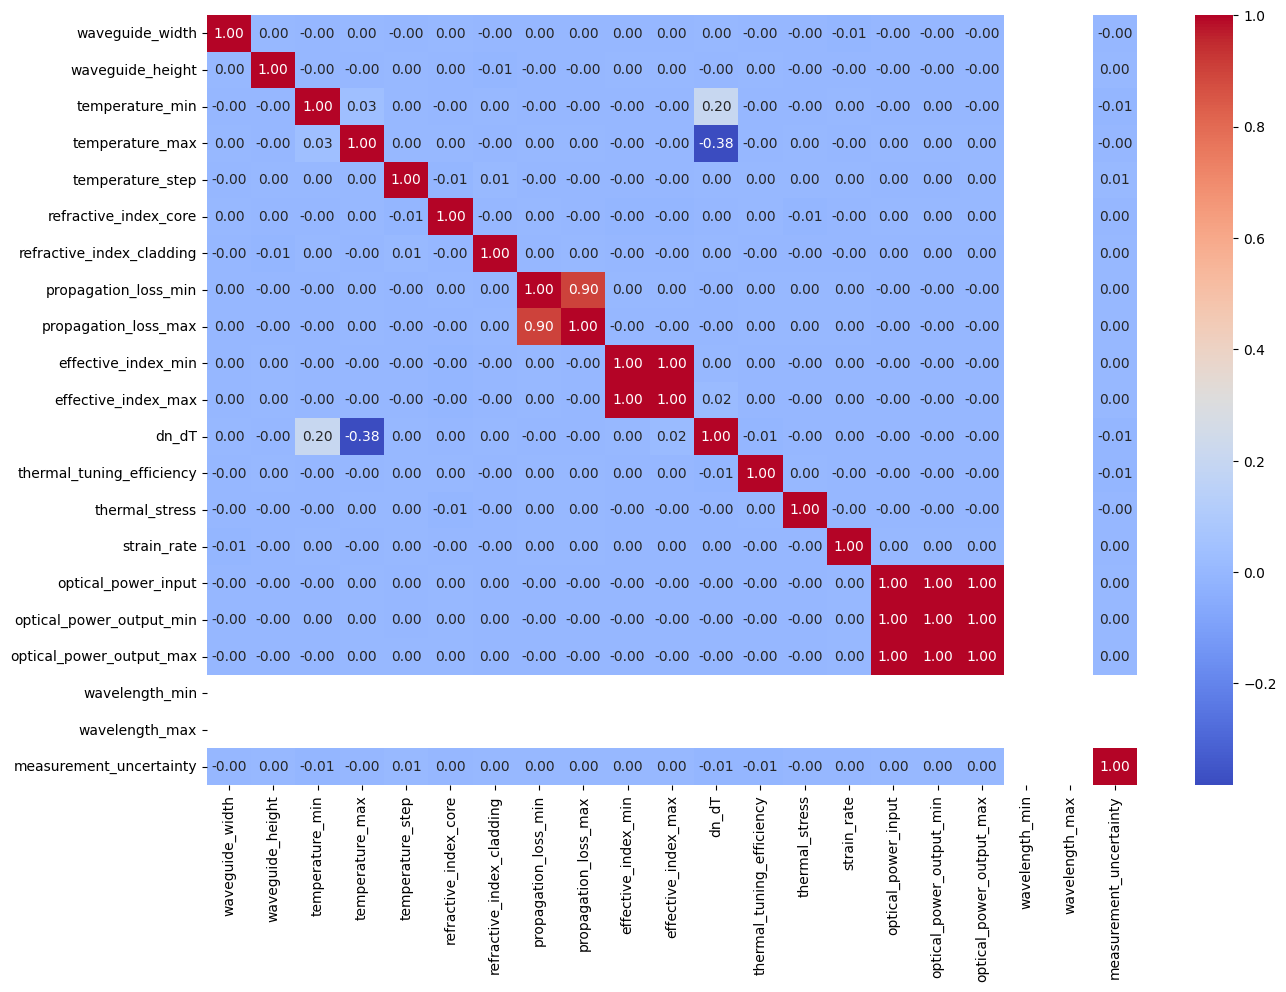

In [27]:
# Correlation matrix
correlation_matrix = df[columns_to_check].corr()

# Plot the correlation matrix

plt.figure(figsize=(15,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

#### Splitting Data in Train and Test

In [28]:
# Separate features (X) and target (y)
X = df.drop(columns=["thermal_tuning_efficiency"])  # Replace "target_column" with the actual column name
y = df["thermal_tuning_efficiency"]

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)

Shape of X_train: (77718, 27)
Shape of y_train: (77718,)


## Linear Regression

### Train Linear Regration (Baseline Model)

In [29]:
# Import LinearRegression from sklearn.linear_model
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

# Evaluation
print("\nLinear Regression Baseline Performance:")
print("MAE:", mean_absolute_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R² Score:", r2_score(y_test, linear_pred))


Linear Regression Baseline Performance:
MAE: 0.8650285243653872
RMSE: 0.9993444179580634
R² Score: -0.00018687179668752663


### Grid Search CV

In [30]:
ridge = Ridge()
# Grid Search
ridge_grid_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(ridge, ridge_grid_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)
ridge_grid_best = ridge_grid.best_estimator_
ridge_grid_mse = mean_squared_error(y_test, ridge_grid_best.predict(X_test))
ridge_grid_r2 = r2_score(y_test, ridge_grid_best.predict(X_test))

# Print Grid Search hyperparameters and scores
print("\nRidge Grid Search Hyperparameters and Scores:")
ridge_grid_results = pd.DataFrame(ridge_grid.cv_results_)[['param_alpha', 'mean_test_score', 'std_test_score']]
ridge_grid_results['mean_test_score'] = -ridge_grid_results['mean_test_score']  # Convert to positive MSE
print(ridge_grid_results)


Ridge Grid Search Hyperparameters and Scores:
   param_alpha  mean_test_score  std_test_score
0          0.1         1.000680        0.004071
1          1.0         1.000673        0.004071
2         10.0         1.000664        0.004078
3        100.0         1.000645        0.004128


### Random Search CV

In [31]:
# Random Search
ridge_random_params = {'alpha': np.logspace(-2, 2, 20)}
ridge_random = RandomizedSearchCV(ridge, ridge_random_params, n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
ridge_random.fit(X_train, y_train)
ridge_random_best = ridge_random.best_estimator_
ridge_random_mse = mean_squared_error(y_test, ridge_random_best.predict(X_test))
ridge_random_r2 = r2_score(y_test, ridge_random_best.predict(X_test))

# Print Random Search hyperparameters and scores
print("\nRidge Random Search Hyperparameters and Scores:")
ridge_random_results = pd.DataFrame(ridge_random.cv_results_)[['param_alpha', 'mean_test_score', 'std_test_score']]
ridge_random_results['mean_test_score'] = -ridge_random_results['mean_test_score']  # Convert to positive MSE
print(ridge_random_results)


Ridge Random Search Hyperparameters and Scores:
   param_alpha  mean_test_score  std_test_score
0     0.010000         1.000683        0.004071
1    37.926902         1.000652        0.004100
2    14.384499         1.000661        0.004082
3     0.016238         1.000683        0.004071
4     0.483293         1.000675        0.004071
5     0.112884         1.000680        0.004071
6     2.069138         1.000671        0.004071
7     0.042813         1.000682        0.004071
8    61.584821         1.000648        0.004113
9    23.357215         1.000657        0.004090


### Bayesian Optimization

In [32]:
# Bayesian Optimization
ridge_bayes_params = {'alpha': (0.1, 100.0, 'log-uniform')}
ridge_bayes = BayesSearchCV(ridge, ridge_bayes_params, n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
ridge_bayes.fit(X_train, y_train)
ridge_bayes_best = ridge_bayes.best_estimator_
ridge_bayes_mse = mean_squared_error(y_test, ridge_bayes_best.predict(X_test))
ridge_bayes_r2 = r2_score(y_test, ridge_bayes_best.predict(X_test))

# Print Bayesian Optimization hyperparameters and scores
print("\nRidge Bayesian Optimization Hyperparameters and Scores:")
ridge_bayes_results = pd.DataFrame({
    'param_alpha': ridge_bayes.cv_results_['param_alpha'],
    'mean_test_score': -ridge_bayes.cv_results_['mean_test_score'],  # Convert to positive MSE
    'std_test_score': ridge_bayes.cv_results_['std_test_score']
})
print(ridge_bayes_results)


Ridge Bayesian Optimization Hyperparameters and Scores:
   param_alpha  mean_test_score  std_test_score
0     1.699464         1.000672        0.004071
1    32.521088         1.000653        0.004096
2     2.160218         1.000671        0.004071
3    27.364528         1.000655        0.004093
4    25.041499         1.000656        0.004091
5    15.925169         1.000660        0.004083
6     7.099669         1.000666        0.004076
7     4.267851         1.000669        0.004073
8    73.524818         1.000647        0.004119
9     0.102539         1.000680        0.004071


### Results Comparison

In [33]:
# Initialize the Linear Regression model as baseline
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
baseline_preds = linear_model.predict(X_test)
baseline_mse = mean_squared_error(y_test, baseline_preds)
baseline_r2 = r2_score(y_test, baseline_preds)


# Create the results DataFrame
results = pd.DataFrame({
    'Model': ['Ridge (Grid)', 'Ridge (Random)', 'Ridge (Bayes)', 'Baseline (Linear Regression)'],
    'Best Params': [ridge_grid.best_params_, ridge_random.best_params_, ridge_bayes.best_params_, 'N/A'],
    'MSE': [ridge_grid_mse, ridge_random_mse, ridge_bayes_mse, baseline_mse],
    'R2': [ridge_grid_r2, ridge_random_r2, ridge_bayes_r2, baseline_r2]
})

# Style the table
print("\nPerformance Metrics:")
styled_results = results.style.format({
    'MSE': '{:.4f}',  # Format MSE to 4 decimal places
    'R2': '{:.4f}'    # Format R2 to 4 decimal places
}).set_properties(**{
    'text-align': 'center',
    'border': '1px solid black',
    'padding': '5px'
}).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center'), ('background-color', '#f2f2f2')]}
])

display(styled_results)


Performance Metrics:


,Model,Best Params,MSE,R2
0,Ridge (Grid),{'alpha': 100.0},0.9987,-0.0002
1,Ridge (Random),{'alpha': np.float64(61.584821106602604)},0.9987,-0.0002
2,Ridge (Bayes),OrderedDict({'alpha': 73.52481813242629}),0.9987,-0.0002
3,Baseline (Linear Regression),N/A,0.9987,-0.0002


C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_10612\1973170358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=results, palette='viridis')


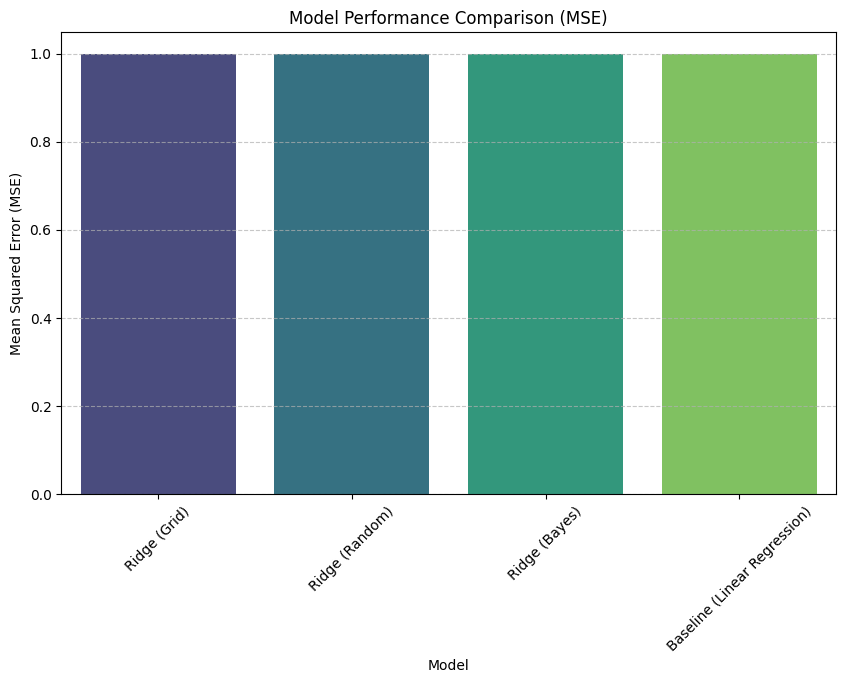

C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_10612\1973170358.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=results, palette='viridis')


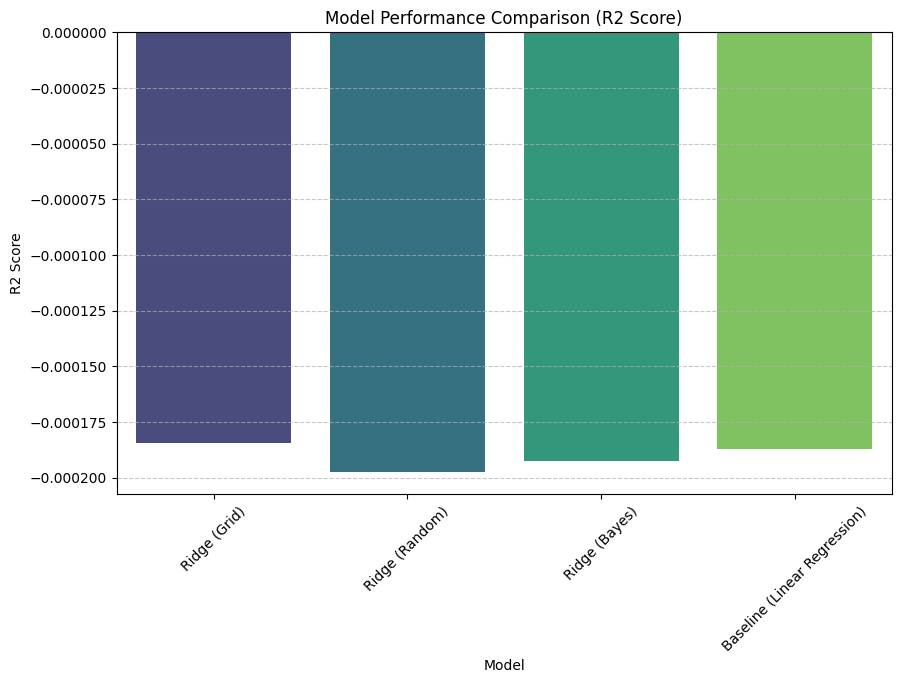

In [34]:
# Plotting the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MSE', data=results, palette='viridis')
plt.title('Model Performance Comparison (MSE)')
plt.xticks(rotation=45)
plt.ylabel('Mean Squared Error (MSE)')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show() 
# Plotting the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2', data=results, palette='viridis')
plt.title('Model Performance Comparison (R2 Score)')
plt.xticks(rotation=45)
plt.ylabel('R2 Score')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Random Forrest

### Train Random Forest (Baseline Model)

In [35]:
default_model = RandomForestRegressor(random_state=42)
default_model.fit(X_train, y_train)
default_pred = default_model.predict(X_test)
# Evaluation
print("\nDefault Model Performance:")
print("MAE:", mean_absolute_error(y_test, default_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, default_pred)))
print("R² Score:", r2_score(y_test, default_pred))


Default Model Performance:
MAE: 0.8685839497607297
RMSE: 1.006662388372543
R² Score: -0.014888783815961482


### Grid Search CV

In [36]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
print("Performing Grid Search...")
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get best model
best_grid_model = grid_search.best_estimator_
grid_pred = best_grid_model.predict(X_test)

# Evaluate model performance
print("\nGrid Search Best Model Performance:")
print("Best Parameters:", grid_search.best_params_)
print("MAE:", mean_absolute_error(y_test, grid_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, grid_pred)))
print("R² Score:", r2_score(y_test, grid_pred))

Performing Grid Search...

Grid Search Best Model Performance:
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
MAE: 0.8652986561442335
RMSE: 0.9996813888272872
R² Score: -0.0008614953920422774


### Random Search CV

In [37]:
param_dist = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [10, 20, 30],
    'min_samples_split': np.arange(2, 11, 2),
    'min_samples_leaf': np.arange(1, 5)
}
print("Performing Random Search...")
random_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist, n_iter=10, cv=3, n_jobs=-1)
random_search.fit(X_train, y_train)

# Get best model
best_random_model = random_search.best_estimator_
random_pred = best_random_model.predict(X_test)

# Evaluate model performance
print("\nRandom Search Best Model Performance:")
print("Best Parameters:", random_search.best_params_)
print("MAE:", mean_absolute_error(y_test, random_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, random_pred)))
print("R² Score:", r2_score(y_test, random_pred))

Performing Random Search...

Random Search Best Model Performance:
Best Parameters: {'n_estimators': np.int64(200), 'min_samples_split': np.int64(8), 'min_samples_leaf': np.int64(3), 'max_depth': 10}
MAE: 0.8651986673039624
RMSE: 0.9996176053850392
R² Score: -0.0007337819914770005


### Bayesian Optimization

In [39]:
def rf_bo(n_estimators, max_depth):
    model = RandomForestRegressor(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        random_state=42
    )
    return cross_val_score(model, X_train, y_train, cv=2, verbose=2, n_jobs=-1, scoring='r2').mean()

print("Performing Bayesian Optimization...")
bo = BayesianOptimization(rf_bo, {'n_estimators': (50, 200), 'max_depth': (10, 30)})
bo.maximize(n_iter=5)

# Get best parameters
best_bo_params = bo.max['params']
best_bo_params['n_estimators'] = int(best_bo_params['n_estimators'])
best_bo_params['max_depth'] = int(best_bo_params['max_depth'])

# Train model with best parameters
best_bo_model = RandomForestRegressor(**best_bo_params, random_state=42)
best_bo_model.fit(X_train, y_train)
bo_pred = best_bo_model.predict(X_test)

# Evaluate model performance
print("\nBayesian Optimization Best Model Performance:")
print("Best Parameters:", best_bo_params)
print("MAE:", mean_absolute_error(y_test, bo_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, bo_pred)))
print("R² Score:", r2_score(y_test, bo_pred))

Performing Bayesian Optimization...
|   iter    |  target   | max_depth | n_esti... |
-------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:  1.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


| 1         | -0.007962 | 25.13     | 135.0     |


[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:  1.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


| 2         | -0.009537 | 24.06     | 95.19     |


...

| 8         | -0.003757 | 17.32     | 162.7     |


[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:   55.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


| 9         | -0.001394 | 10.07     | 171.0     |


[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:   59.7s finished


| 10        | -0.001387 | 10.36     | 183.1     |

Bayesian Optimization Best Model Performance:
Best Parameters: {'max_depth': 10, 'n_estimators': 183}
MAE: 0.865195481273539
RMSE: 0.999649887472818
R² Score: -0.0007984193033205855


### Compare Hyperparameter Tuning Results

In [40]:
results = pd.DataFrame({
    "Method": ["Base Line","Grid Search", "Random Search", "Bayesian Optimization"],
    "Best R² Score": [r2_score(y_test, default_pred),r2_score(y_test, grid_pred), r2_score(y_test, random_pred), r2_score(y_test, bo_pred)]
})
print(results)

                  Method  Best R² Score
0              Base Line      -0.014889
1            Grid Search      -0.000861
2          Random Search      -0.000734
3  Bayesian Optimization      -0.000798


C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_10612\2447728295.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results["Method"], y=results["Best R² Score"], palette='viridis')


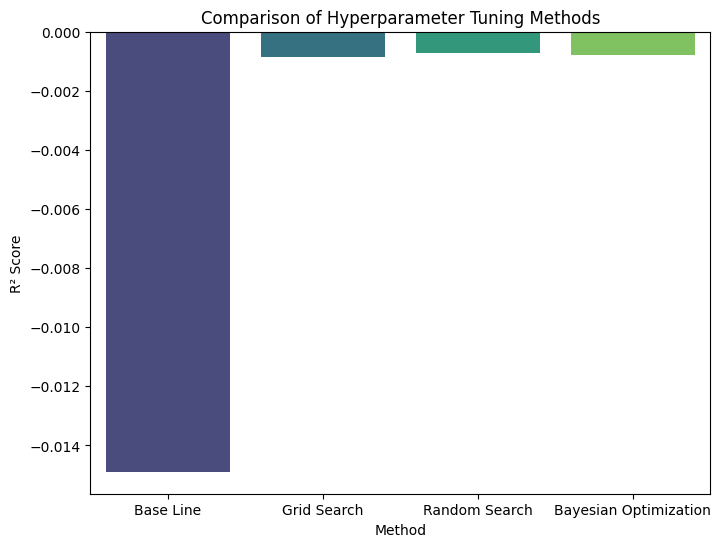

In [41]:
# Plot results
plt.figure(figsize=(8,6))
sns.barplot(x=results["Method"], y=results["Best R² Score"], palette='viridis')
plt.title("Comparison of Hyperparameter Tuning Methods")
plt.ylabel("R² Score")
plt.show()

## XGBoost

In [42]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluates a regression model using RMSE, MAE, and R² score.

    Parameters:
    model: Trained regression model
    X_test: Test feature set
    y_test: True target values

    Returns:
    Dictionary with RMSE, MAE, and R² score.
    """
    y_pred = model.predict(X_test)
    return {
        "RMSE": root_mean_squared_error(y_test, y_pred),  # Updated function
        "MAE": mean_absolute_error(y_test, y_pred),
        "R²": r2_score(y_test, y_pred)
    }


In [43]:
# Create a scorer function for RMSE
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)


### Training XGBoost Model

In [44]:

model = XGBRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Root Mean Squared Error:", np.sqrt(mse))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


Root Mean Squared Error: 1.0187570600455418
Mean Absolute Error: 0.8765765648901543
R² Score: -0.039422301725906994


### Hyperparameter Tuning

### Grid Search CV

In [46]:
xgb = XGBRegressor(objective="reg:squarederror", random_state=42)

param_grid = {
    "n_estimators": [50,100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [1, 5, 7],
    'subsample': [0.3,0.5,0.7]
}

grid_search = GridSearchCV(
    estimator=xgb,               # The model to tune
    param_grid=param_grid,           # The parameter grid we defined
    cv=3,                            # 5-fold cross-validation
    scoring= rmse_scorer ,          # Performance metric (Lower MSE is better)
    n_jobs=-1,                       # Uses all CPU cores for parallel computation
    verbose=2,
    return_train_score=True         # Include training scores
)

grid_search.fit(X_train, y_train)

grid_results = evaluate_model(grid_search.best_estimator_, X_test, y_test)
print(grid_results)
print("Best Parameters (GridSearchCV):", grid_search.best_params_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
{'RMSE': 0.9992313263118173, 'MAE': 0.8649629214516399, 'R²': 3.9489360890487823e-05}
Best Parameters (GridSearchCV): {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.7}


### Random Search CV

In [48]:
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.7, 0.3)
}

random_search = RandomizedSearchCV(
    estimator=xgb, # The model to tune
    param_distributions=param_dist, # The parameter distribution to sample from
    n_iter=100, # The number of parameter settings that are sampled
    cv=2, # 5-fold cross-validation
    scoring=rmse_scorer, # Lower MSE is better
    n_jobs=-1, # Uses all CPU cores
    verbose=2, # Displays progress
    random_state=42,
    return_train_score=True # Include training scores
)
random_search.fit(X_train, y_train)

random_results = evaluate_model(random_search.best_estimator_, X_test, y_test)
print(random_results)
print("Best Parameters (RandomizedSearchCV):", random_search.best_params_)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
{'RMSE': 0.9992470335599665, 'MAE': 0.8649783704457233, 'R²': 8.051692924726517e-06}
Best Parameters (RandomizedSearchCV): {'learning_rate': np.float64(0.021066084206359838), 'max_depth': 3, 'n_estimators': 51, 'subsample': np.float64(0.8508037069686584)}


### Bayesian Optimization

In [50]:
bayes_search = BayesSearchCV(
    xgb,
    {
        "n_estimators": (50, 100, 300),
        "learning_rate": (0.01, 0.1, 0.2),
        "max_depth": (3, 5, 7, 10)
    },
    n_iter=20,
    cv=2,
    scoring=rmse_scorer,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

bayes_search.fit(X_train, y_train)

bayes_results = evaluate_model(bayes_search.best_estimator_, X_test, y_test)
print(bayes_results)
print("Best Parameters (Bayesian Optimization):", bayes_search.best_params_)


Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fi

### Performance Comparison Table

In [51]:
# 1️⃣ GridSearchCV Best Model
best_grid = grid_search.best_estimator_
y_pred_grid = best_grid.predict(X_test)
mse_grid = mean_squared_error(y_test, y_pred_grid)
rmse_grid = np.sqrt(mse_grid)
r2_grid = r2_score(y_test, y_pred_grid)

# 2️⃣ RandomizedSearchCV Best Model
best_random = random_search.best_estimator_
y_pred_random = best_random.predict(X_test)
mse_random = mean_squared_error(y_test, y_pred_random)
rmse_random = np.sqrt(mse_random)
r2_random = r2_score(y_test, y_pred_random)

# 3️⃣ Bayesian Optimization Best Model
best_optuna = bayes_search.best_estimator_
y_pred_optuna = best_optuna.predict(X_test)
mse_optuna = mean_squared_error(y_test, y_pred_optuna)
rmse_optuna = np.sqrt(mse_optuna)
r2_optuna = r2_score(y_test, y_pred_optuna)

#  Display results
print("\n--- Model Performance Comparison ---")
print(f"GridSearchCV   -> MSE: {mse_grid:.4f}, RMSE: {rmse_grid:.4f}, R2: {r2_grid:.4f}")
print(f"RandomSearchCV -> MSE: {mse_random:.4f}, RMSE: {rmse_random:.4f}, R2: {r2_random:.4f}")
print(f"Optuna (Bayesian) -> MSE: {mse_optuna:.4f}, RMSE: {rmse_optuna:.4f}, R2: {r2_optuna:.4f}")



--- Model Performance Comparison ---
GridSearchCV   -> MSE: 0.9985, RMSE: 0.9992, R2: 0.0000
RandomSearchCV -> MSE: 0.9985, RMSE: 0.9992, R2: 0.0000
Optuna (Bayesian) -> MSE: 0.9984, RMSE: 0.9992, R2: 0.0001


In [52]:
results = pd.DataFrame({
    'Model': ['GridSearchCV', 'RandomizedSearchCV', 'Optuna (Bayesian)'],
    'MSE': [mse_grid, mse_random, mse_optuna],
    'RMSE': [rmse_grid, rmse_random, rmse_optuna],
    'R2 Score': [r2_grid, r2_random, r2_optuna]
})

print("\n--- Comparison Table ---")
print(results)


--- Comparison Table ---
                Model       MSE      RMSE  R2 Score
0        GridSearchCV  0.998463  0.999231  0.000039
1  RandomizedSearchCV  0.998495  0.999247  0.000008
2   Optuna (Bayesian)  0.998434  0.999217  0.000068


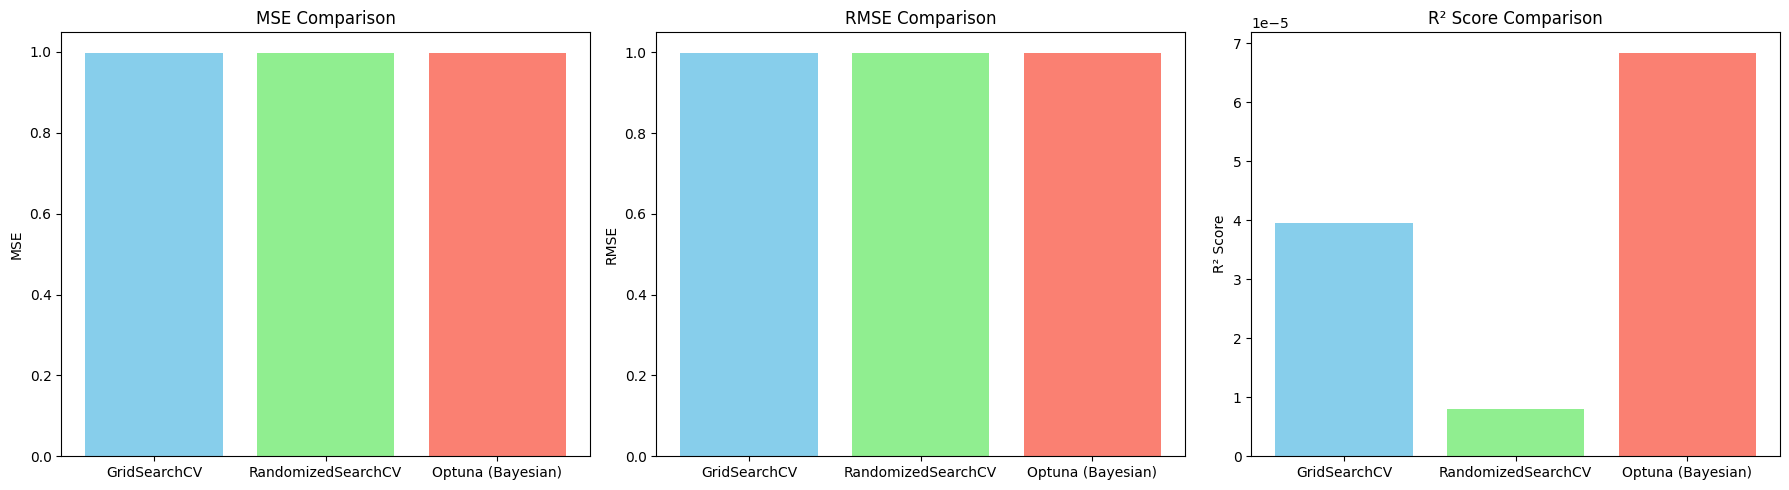

In [53]:
# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18,5))

# MSE Plot
axs[0].bar(results['Model'], results['MSE'], color=['skyblue', 'lightgreen', 'salmon'])
axs[0].set_title('MSE Comparison')
axs[0].set_ylabel('MSE')

# RMSE Plot
axs[1].bar(results['Model'], results['RMSE'], color=['skyblue', 'lightgreen', 'salmon'])
axs[1].set_title('RMSE Comparison')
axs[1].set_ylabel('RMSE')

# R2 Score Plot
axs[2].bar(results['Model'], results['R2 Score'], color=['skyblue', 'lightgreen', 'salmon'])
axs[2].set_title('R² Score Comparison')
axs[2].set_ylabel('R² Score')

plt.tight_layout()
plt.show()


## Multi Layer Perception

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu'],
    'solver': ['sgd'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate': ['adaptive'],
    'max_iter': [500]
}

param_dist = {
    'hidden_layer_sizes': [(np.random.randint(50, 200),), (np.random.randint(50, 200), np.random.randint(50, 200))],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': loguniform(1e-4, 1e-1),
    'learning_rate': ['adaptive'],
    'max_iter': [500]
}

param_bayes = {
    'hidden_layer_1': Integer(50, 200),
    'hidden_layer_2': Integer(0, 200),  # 0 means "don't use"
    'activation': Categorical(['relu']),
    'solver': Categorical(['adam']),
    'alpha': Real(1e-4, 1e-1, prior='log-uniform'),
    'learning_rate': Categorical([ 'adaptive']),
    'max_iter': Integer(500)
}

### Grid Search CV

In [55]:
grid_search = GridSearchCV(
  MLPRegressor(random_state=42),
  param_grid,
  scoring='neg_mean_squared_error',
  cv=2,
  n_jobs=-1,
  verbose=3,
  return_train_score=True
)
grid_search.fit(X_train, y_train)

print("Best GridSearchCV Parameters:", grid_search.best_params_)
print("Best GridSearchCV Score:", -grid_search.best_score_)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
Best GridSearchCV Parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,), 'learning_rate': 'adaptive', 'max_iter': 500, 'solver': 'sgd'}
Best GridSearchCV Score: 1.0048869550981827


### Random Search CV

In [56]:
random_search = RandomizedSearchCV(
    MLPRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=2,
    n_jobs=-1,
    random_state=42,
    verbose=3,
    return_train_score=True
)
random_search.fit(X_train, y_train)

print("Best RandomizedSearchCV Parameters:", random_search.best_params_)
print("Best RandomizedSearchCV Score:", -random_search.best_score_)

Fitting 2 folds for each of 20 candidates, totalling 40 fits
Best RandomizedSearchCV Parameters: {'activation': 'tanh', 'alpha': np.float64(0.01129013355909268), 'hidden_layer_sizes': (69,), 'learning_rate': 'adaptive', 'max_iter': 500, 'solver': 'sgd'}
Best RandomizedSearchCV Score: 1.0045235230291505


### Bayesian Optimization

In [60]:
class CustomMLP(MLPRegressor):
    def set_params(self, **params):
        # Combine two layer sizes into hidden_layer_sizes tuple
        hl1 = params.pop('hidden_layer_1', 100)
        hl2 = params.pop('hidden_layer_2', 0)
        if hl2 > 0:
            params['hidden_layer_sizes'] = (hl1, hl2)
        else:
            params['hidden_layer_sizes'] = (hl1,)
        return super().set_params(**params)


bayes_search = BayesSearchCV(
    estimator=CustomMLP(random_state=42),
    search_spaces=param_bayes,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=2,
    n_jobs=-1,
    verbose=3
)

bayes_search.fit(X_train, y_train)

print("Best Bayesian Optimization Parameters:", bayes_search.best_params_)
print("Best Bayesian Optimization Score:", -bayes_search.best_score_)

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best Bayesian Optimization Parameters: OrderedDict({'activation': 'tanh', 'alpha': 0.0022094113351760454, 'hidden_layer_1': 60, 'hidden_layer_2': 6, 'learning_rate': 'constant', 'max_iter': 642, 'solver': 'sgd'})
Best Bayesian Optimization Score: 1.0027662533657593


### Comparison of Hyperparameter Tuning Techniques

In [61]:
print("GridSearchCV:")
print("Best Score (MSE):", grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

print("\nRandomizedSearchCV:")
print("Best Score (MSE):", random_search.best_score_)
print("Best Params:", random_search.best_params_)

print("\nBayesSearchCV:")
print("Best Score (MSE):", -bayes_search.best_score_)
print("Best Params:", bayes_search.best_params_)

GridSearchCV:
Best Score (MSE): -1.0048869550981827
Best Params: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,), 'learning_rate': 'adaptive', 'max_iter': 500, 'solver': 'sgd'}

RandomizedSearchCV:
Best Score (MSE): -1.0045235230291505
Best Params: {'activation': 'tanh', 'alpha': np.float64(0.01129013355909268), 'hidden_layer_sizes': (69,), 'learning_rate': 'adaptive', 'max_iter': 500, 'solver': 'sgd'}

BayesSearchCV:
Best Score (MSE): 1.0027662533657593
Best Params: OrderedDict({'activation': 'tanh', 'alpha': 0.0022094113351760454, 'hidden_layer_1': 60, 'hidden_layer_2': 6, 'learning_rate': 'constant', 'max_iter': 642, 'solver': 'sgd'})


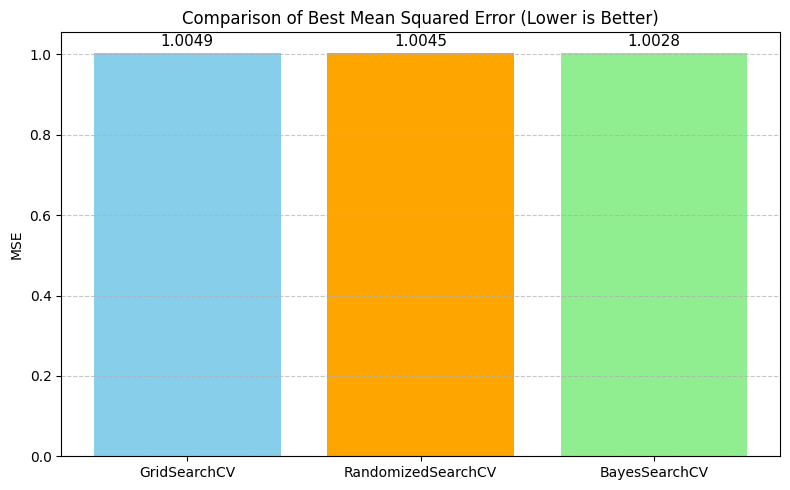

In [62]:
results = {
    'GridSearchCV': -grid_search.best_score_,
    'RandomizedSearchCV': -random_search.best_score_,
    'BayesSearchCV': -bayes_search.best_score_
}

# bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), results.values(), color=['skyblue', 'orange', 'lightgreen'])

# Annotate each bar with score
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5), textcoords='offset points', ha='center', fontsize=11)

plt.title('Comparison of Best Mean Squared Error (Lower is Better)')
plt.ylabel('MSE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## k-Nearest Neighbors

### Grid Search CV

In [63]:
knn = KNeighborsRegressor()
knn_grid_params = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(knn, knn_grid_params, cv=3, scoring='neg_mean_squared_error')
knn_grid.fit(X_train, y_train)
knn_grid_best = knn_grid.best_estimator_
knn_grid_mse = mean_squared_error(y_test, knn_grid_best.predict(X_test))
knn_grid_r2 = r2_score(y_test, knn_grid_best.predict(X_test))

# Print Grid Search hyperparameters and scores
print("\nKNN Grid Search Hyperparameters and Scores:")
knn_grid_results = pd.DataFrame(knn_grid.cv_results_)[['param_n_neighbors', 'param_weights', 'mean_test_score', 'std_test_score']]
knn_grid_results['mean_test_score'] = -knn_grid_results['mean_test_score']  # Convert to positive MSE
print(knn_grid_results)


KNN Grid Search Hyperparameters and Scores:
   param_n_neighbors param_weights  mean_test_score  std_test_score
0                  3       uniform         1.338843        0.010198
1                  3      distance         1.340608        0.010322
2                  5       uniform         1.201008        0.006032
3                  5      distance         1.202588        0.006191
4                  7       uniform         1.144241        0.006417
5                  7      distance         1.145337        0.006546
6                  9       uniform         1.112661        0.006852
7                  9      distance         1.113582        0.006938


### Random Search CV

In [64]:
# Random Search
knn_random_params = {'n_neighbors': np.arange(3, 15), 'weights': ['uniform', 'distance']}
knn_random = RandomizedSearchCV(knn, knn_random_params, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42)
knn_random.fit(X_train, y_train)
knn_random_best = knn_random.best_estimator_
knn_random_mse = mean_squared_error(y_test, knn_random_best.predict(X_test))
knn_random_r2 = r2_score(y_test, knn_random_best.predict(X_test))

# Print Random Search hyperparameters and scores
print("\nKNN Random Search Hyperparameters and Scores:")
knn_random_results = pd.DataFrame(knn_random.cv_results_)[['param_n_neighbors', 'param_weights', 'mean_test_score', 'std_test_score']]
knn_random_results['mean_test_score'] = -knn_random_results['mean_test_score']  # Convert to positive MSE
print(knn_random_results)


KNN Random Search Hyperparameters and Scores:
   param_n_neighbors param_weights  mean_test_score  std_test_score
0                  7       uniform         1.144241        0.006417
1                 11       uniform         1.092280        0.005948
2                  3       uniform         1.338843        0.010198
3                 12       uniform         1.085192        0.006755
4                  8      distance         1.127097        0.007285
5                  7      distance         1.145337        0.006546
6                  9      distance         1.113582        0.006938
7                  3      distance         1.340608        0.010322
8                 13      distance         1.077694        0.005993
9                  5      distance         1.202588        0.006191


### Bayesian Optimization

In [65]:
# Bayesian Optimization
knn_bayes_params = {'n_neighbors': (3, 15), 'weights': ['uniform', 'distance']}
knn_bayes = BayesSearchCV(knn, knn_bayes_params, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42)
knn_bayes.fit(X_train, y_train)
knn_bayes_best = knn_bayes.best_estimator_
knn_bayes_mse = mean_squared_error(y_test, knn_bayes_best.predict(X_test))
knn_bayes_r2 = r2_score(y_test, knn_bayes_best.predict(X_test))

# Print Bayesian Optimization hyperparameters and scores
print("\nKNN Bayesian Optimization Hyperparameters and Scores:")
knn_bayes_results = pd.DataFrame({
    'param_n_neighbors': knn_bayes.cv_results_['param_n_neighbors'],
    'param_weights': knn_bayes.cv_results_['param_weights'],
    'mean_test_score': -knn_bayes.cv_results_['mean_test_score'],  # Convert to positive MSE
    'std_test_score': knn_bayes.cv_results_['std_test_score']
})
print(knn_bayes_results)


KNN Bayesian Optimization Hyperparameters and Scores:
   param_n_neighbors param_weights  mean_test_score  std_test_score
0                  8      distance         1.127097        0.007285
1                 13      distance         1.077694        0.005993
2                  8      distance         1.127097        0.007285
3                 13       uniform         1.076882        0.005892
4                 13       uniform         1.076882        0.005892
5                 12      distance         1.085893        0.006797
6                 10      distance         1.102229        0.006828
7                 10      distance         1.102229        0.006828
8                 14      distance         1.072322        0.006329
9                  3      distance         1.340608        0.010322


### Results Comparison

In [66]:
results = pd.DataFrame({
    'Model': ['KNN (Grid)', 'KNN (Random)', 'KNN (Bayes)'],
    'Best Params': [knn_grid.best_params_, knn_random.best_params_, knn_bayes.best_params_],
    'MSE': [ knn_grid_mse, knn_random_mse, knn_bayes_mse],
    'R2': [knn_grid_r2, knn_random_r2, knn_bayes_r2]
})

# Style the table
print("\nPerformance Metrics:")
styled_results = results.style.format({
    'MSE': '{:.4f}',  # Format MSE to 4 decimal places
    'R2': '{:.4f}'    # Format R2 to 4 decimal places
}).set_properties(**{
    'text-align': 'center',  # Center-align text
    'border': '1px solid black',  # Add borders
    'padding': '5px'  # Add padding
}).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center'), ('background-color', '#f2f2f2')]}
])  # Style headers

display(styled_results)


Performance Metrics:


,Model,Best Params,MSE,R2
0,KNN (Grid),"{'n_neighbors': 9, 'weights': 'uniform'}",1.1092,-0.1108
1,KNN (Random),"{'weights': 'distance', 'n_neighbors': np.int64(13)}",1.0804,-0.0820
2,KNN (Bayes),"OrderedDict({'n_neighbors': 14, 'weights': 'distance'})",1.0741,-0.0757


C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_10612\2279662525.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='R2', data=results_sorted, palette='viridis')


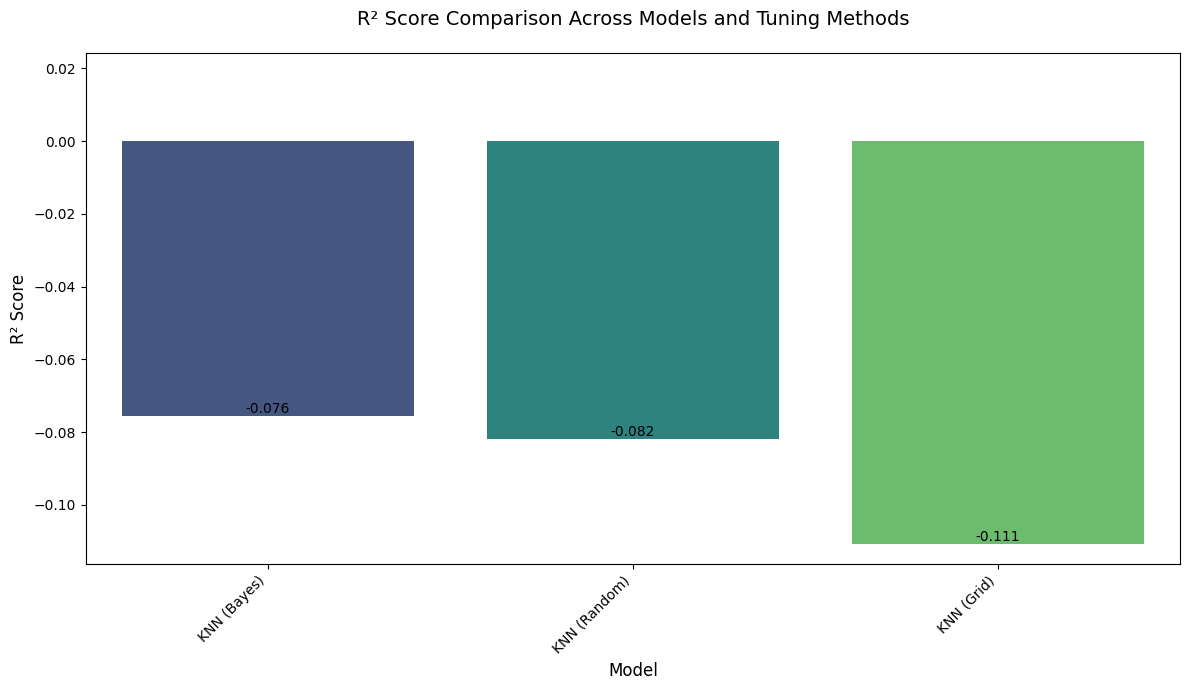

In [67]:
plt.figure(figsize=(12, 7))  # Adjusted figure size for better spacing

# Sort models by R² score descending
results_sorted = results.sort_values('R2', ascending=False)

# Create bar plot with sorted data
ax = sns.barplot(x='Model', y='R2', data=results_sorted, palette='viridis')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.title('R² Score Comparison Across Models and Tuning Methods', fontsize=14, pad=20)
plt.xlabel('Model', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Better alignment for rotated labels
plt.ylim(top=min(1.0, results['R2'].max() + 0.1))  # Adjust y-axis limit if needed

# Improve layout spacing
plt.tight_layout()
plt.show()